In [1]:
# 1. Clona il repository
!git clone https://github.com/MisterCioffi/SteganoGAN.git

# 2. Entra nella cartella del progetto
%cd SteganoGAN

# 3. Rimuovi i limiti superiori stringenti dal file setup.py
with open('setup.py', 'r') as f:
    setup_content = f.read()

# Rimuoviamo i vincoli superiori che rompono Colab
setup_content = setup_content.replace('<2.5.0', '')
setup_content = setup_content.replace('<1.2.0', '')
setup_content = setup_content.replace('<1.16.0', '')
setup_content = setup_content.replace('<8.0.0', '')
setup_content = setup_content.replace('<2.0.0', '')

with open('setup.py', 'w') as f:
    f.write(setup_content)

print("setup.py patchato con successo!")

fatal: destination path 'SteganoGAN' already exists and is not an empty directory.
/content/SteganoGAN
setup.py patchato con successo!


In [2]:
# Installa le dipendenze e il pacchetto
!pip install -e .

Obtaining file:///content/SteganoGAN
  Preparing metadata (setup.py) ... done
  Attempting uninstall: steganogan
    Found existing installation: steganogan 0.1.4.dev0
    Uninstalling steganogan-0.1.4.dev0:
      Successfully uninstalled steganogan-0.1.4.dev0
  Running setup.py develop for steganogan


In [4]:
from PIL import Image

def ritaglia_al_centro(percorso_input, percorso_output, dimensione=512):
    """
    Prende un'immagine, la ritaglia esattamente al centro con le dimensioni richieste
    e la salva come nuovo file.
    """
    # 1. Apri l'immagine
    img = Image.open(percorso_input)
    larghezza, altezza = img.size

    print(f"Dimensioni originali: {larghezza}x{altezza}")

    # 2. Verifica che l'immagine sia grande abbastanza
    if larghezza < dimensione or altezza < dimensione:
        print("Errore: L'immagine è più piccola di 512x512, usane una più grande!")
        return

    # 3. Calcola le coordinate matematiche per il ritaglio centrale
    sinistra = (larghezza - dimensione) / 2
    alto = (altezza - dimensione) / 2
    destra = (larghezza + dimensione) / 2
    basso = (altezza + dimensione) / 2

    # 4. Esegui il taglio
    img_ritagliata = img.crop((sinistra, alto, destra, basso))

    # 5. Salva la nuova immagine
    img_ritagliata.save(percorso_output)
    print(f"Fatto! Immagine perfetta salvata in '{percorso_output}' con dimensioni: {img_ritagliata.size}")

In [7]:
# --- ESEGUI IL TAGLIO ---
# Inserisci il nome della tua foto reale originale e il nome del nuovo file
ritaglia_al_centro('research/input.png', 'research/input_512.png', 512)

Dimensioni originali: 2040x1152
Fatto! Immagine perfetta salvata in 'research/input_512.png' con dimensioni: (512, 512)


In [8]:
import os
import torch
import torch.optim
import torch.optim.adam
import steganogan.models
from steganogan import SteganoGAN
import numpy as np
import skimage.io as io

# --- 1. PATCH PER L'OTTIMIZZATORE ADAM (Livello 1 e 2) ---
_original_optimizer_setstate = torch.optim.Optimizer.__setstate__
def _safe_setstate(self, state):
    if isinstance(state, dict) and 'defaults' not in state:
        state['defaults'] = {}
    try:
        _original_optimizer_setstate(self, state)
    except Exception:
        pass
torch.optim.Optimizer.__setstate__ = _safe_setstate

# NOVITÀ: Patch specifica per Adam per l'errore param_groups
_original_adam_setstate = torch.optim.Adam.__setstate__
def _safe_adam_setstate(self, state):
    if not hasattr(self, 'param_groups'):
        self.param_groups = []  # Gli diamo una lista vuota per non farlo arrabbiare
    try:
        _original_adam_setstate(self, state)
    except Exception:
        pass
torch.optim.Adam.__setstate__ = _safe_adam_setstate


# --- 2. PATCH PER LA SICUREZZA DI PYTORCH 2.6+ ---
@classmethod
def custom_load(cls, architecture=None, path=None, cuda=True, verbose=False):
    if architecture and not path:
        model_name = '{}.steg'.format(architecture)
        pretrained_path = os.path.join(os.path.dirname(steganogan.models.__file__), 'pretrained')
        path = os.path.join(pretrained_path, model_name)
    elif (architecture is None and path is None) or (architecture and path):
        raise ValueError('Please provide either an architecture or a path to pretrained model.')

    # weights_only=False per bypassare il blocco di sicurezza
    steganogan_model = torch.load(path, map_location='cpu', weights_only=False)
    steganogan_model.verbose = verbose

    steganogan_model.encoder.upgrade_legacy()
    steganogan_model.decoder.upgrade_legacy()
    steganogan_model.critic.upgrade_legacy()

    steganogan_model.set_device(cuda)
    return steganogan_model

SteganoGAN.load = custom_load


# --- 3. IL TEST FINALE ---
print("Caricamento del modello (con Super Patch 2.0 attiva)...")
steganogan_model = SteganoGAN.load(architecture='dense')

# Ora proviamo finalmente il Logo!
cover_image_path = 'research/input_512.png'
stego_image_path = 'output.png'
messaggio_segreto = "https://it.wikipedia.org/wiki/Pongo_pygmaeus"

print("\nNascondo il messaggio nel Logo...")
steganogan_model.encode(cover_image_path, stego_image_path, messaggio_segreto)
print(f"Immagine salvata in: {stego_image_path}")

x = np.float64(io.imread(cover_image_path))
z = np.float64(io.imread(stego_image_path))
MSE = np.mean((x-z)**2)

print("MSE: ", MSE)

print("\nEstraggo il messaggio dal Logo modificato...")
messaggio_decodificato = steganogan_model.decode(stego_image_path)

print("\n--- RISULTATO ---")
print(f"Messaggio estratto: {messaggio_decodificato}")

Caricamento del modello (con Super Patch 2.0 attiva)...

Nascondo il messaggio nel Logo...
Immagine salvata in: output.png
MSE:  12.976577758789062

Estraggo il messaggio dal Logo modificato...

--- RISULTATO ---
Messaggio estratto: https://it.wikipedia.org/wiki/Pongo_pygmaeus


In [9]:
import torchvision.transforms as transforms
from PIL import Image

def interroga_il_critic(percorso_immagine, modello):
    """
    Legge un'immagine e chiede al Critic di valutarla.
    Restituisce un numero: > 0 (Tende al Reale), < 0 (Tende al Falso/Modificato)
    """
    # 1. Carica l'immagine a colori
    img = Image.open(percorso_immagine).convert('RGB')

    # 2. Trasforma l'immagine in Tensore e normalizza i pixel tra 0 e 1
    trasformazione = transforms.ToTensor()
    img_tensor = trasformazione(img).unsqueeze(0) # unsqueeze aggiunge la dimensione 'Batch' (1, 3, H, W)

    # 3. Sposta i dati sulla CPU o GPU (in base a dove sta girando il modello)
    img_tensor = img_tensor.to(modello.device)

    # 4. Chiedi il parere al Critic senza allenarlo (no_grad)
    with torch.no_grad():
        score_tensor = modello.critic(img_tensor)

    # 5. Fai la media per ottenere il voto finale (torch.mean)
    voto_finale = score_tensor.mean().item()
    return voto_finale

In [10]:
stego_image_path_input = 'research/input_512.png'
wasse_in = interroga_il_critic(stego_image_path_input, steganogan_model)
print("input:",wasse_in)

stego_image_path_output = 'output.png'
wasse_out = interroga_il_critic(stego_image_path_output, steganogan_model)
print("output:",wasse_out)


wasse_loss = wasse_out - wasse_in
print(wasse_loss)

input: -0.03899036720395088
output: -0.039735931903123856
-0.0007455646991729736


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def crea_mappa_rumore(path_originale, path_stego, amplificazione=30):
    """
    Calcola la differenza tra l'immagine originale e quella modificata,
    e la mostra come una mappa di calore (Heatmap).
    Richiede che le immagini abbiano la stessa identica dimensione per evitare artefatti.
    """
    print(f"Generazione Mappa di Calore per: {path_originale} vs {path_stego}")

    # 1. Carica le immagini con PIL
    img_orig_pil = Image.open(path_originale).convert('RGB')
    img_stego_pil = Image.open(path_stego).convert('RGB')

    # --- NUOVO CONTROLLO DI SICUREZZA ---
    # Ci assicuriamo che le dimensioni siano identiche. Niente più ridimensionamenti automatici!
    if img_orig_pil.size != img_stego_pil.size:
        raise ValueError(
            f"ERRORE: Le dimensioni non combaciano! Originale {img_orig_pil.size} vs Stego {img_stego_pil.size}.\n"
            f"Per una mappa termica pura, devi prima ritagliare l'immagine originale "
            f"usando l'altro script, in modo che SteganoGAN non ne alteri la risoluzione."
        )

    # 2. Converti in matrici NumPy per fare i calcoli
    img_orig = np.array(img_orig_pil, dtype=np.float32)
    img_stego = np.array(img_stego_pil, dtype=np.float32)

    # 3. Calcola la differenza assoluta pixel per pixel
    differenza = np.abs(img_orig - img_stego)

    # 4. Fai la media sui 3 canali (Rosso, Verde, Blu) per avere un'unica scala di grigi
    mappa_2d = np.mean(differenza, axis=2)

    # 5. Moltiplica per rendere visibile il rumore all'occhio umano
    mappa_amplificata = np.clip(mappa_2d * amplificazione, 0, 255)

    # 6. Disegna il grafico
    plt.figure(figsize=(10, 8))
    plt.title(f"Mappa del Rumore Pura (Amplificata {amplificazione}x)")
    plt.imshow(mappa_amplificata, cmap='hot')
    plt.colorbar(label="Intensità del Rumore Steganografico")
    plt.axis('off')
    plt.show()

# --- ESECUZIONE DEL TEST PULITO ---
# Ricorda di usare il file generato dallo script di ritaglio (es. 'input_512.png')
# crea_mappa_rumore('input_512.png', 'output_512.png')

Generazione Mappa di Calore per: research/input_512.png vs output.png


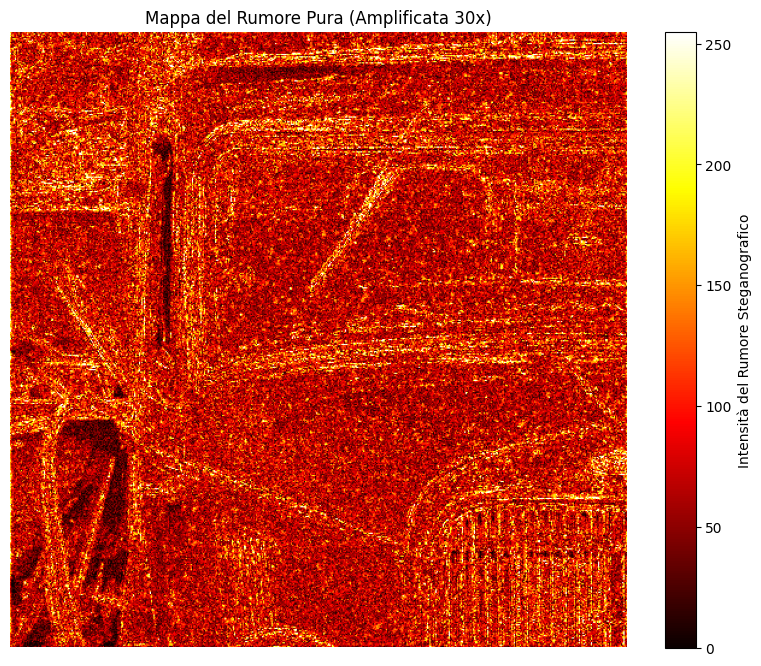

Generazione Mappa di Calore per: research/balls.png vs output_b.png


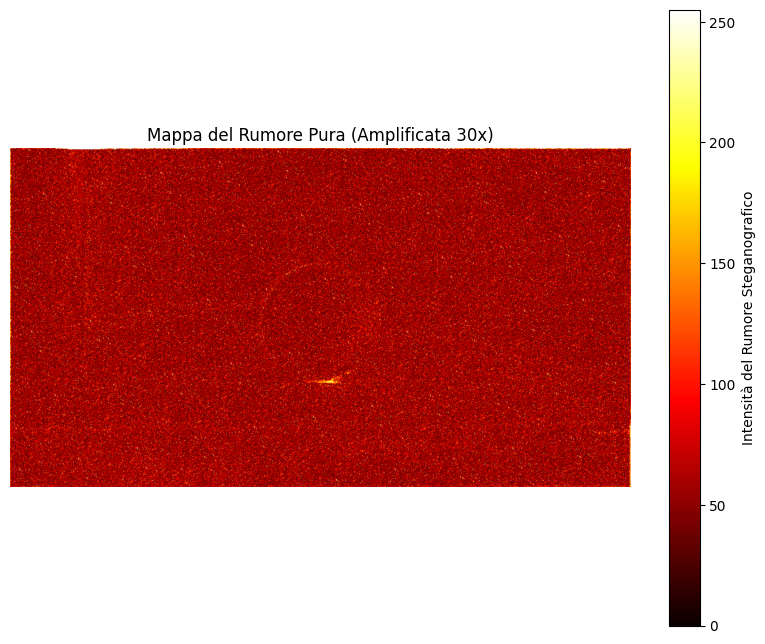

Generazione Mappa di Calore per: research/cyberpunk.png vs output_c.png


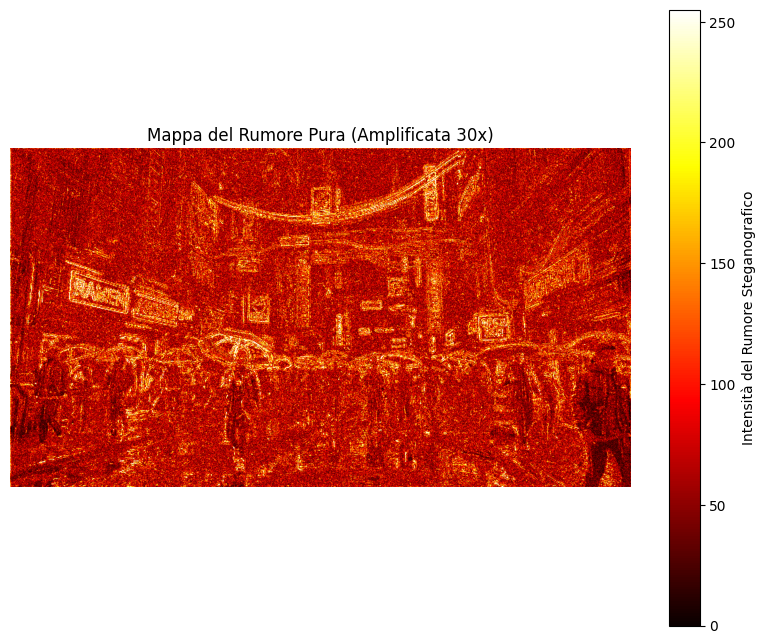

In [12]:
crea_mappa_rumore('research/input_512.png', 'output.png')
crea_mappa_rumore('research/balls.png', 'output_b.png')
crea_mappa_rumore('research/cyberpunk.png', 'output_c.png')